In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/cleaned_house_price.csv")

In [ ]:
df.head()

,area_type,location,Area,bath,balcony,price,bhk,area_per_bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,2.0,39.07,2,528.0
1,Super built-up Area,Lingadheeranahalli,1521.0,3.0,3.0,95.00,3,507.0
2,Super built-up Area,Whitefield,1170.0,2.0,2.0,38.00,2,585.0
3,Super built-up Area,7th Phase JP Nagar,1000.0,2.0,2.0,38.00,2,500.0
4,Plot Area,Sarjapur,2250.0,3.0,3.0,148.00,3,750.0


In [ ]:
df.tail()

,area_type,location,Area,bath,balcony,price,bhk,area_per_bhk
6223,Super built-up Area,Raja Rajeshwari Nagar,1187.0,2.0,2.0,40.14,2,593.500000
6224,Built-up Area,Bannerghatta Road,1527.0,3.0,3.0,142.00,3,509.000000
6225,Super built-up Area,Yeshwanthpur,1675.0,3.0,3.0,92.13,3,558.333333
6226,Super built-up Area,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667
6227,Built-up Area,Raja Rajeshwari Nagar,1141.0,2.0,2.0,60.00,2,570.500000


In [ ]:
df.shape

(6228, 8)

In [ ]:
df.columns

Index(['area_type', 'location', 'Area', 'bath', 'balcony', 'price', 'bhk',
       'area_per_bhk'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6228 entries, 0 to 6227
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     6228 non-null   object 
 1   location      6228 non-null   object 
 2   Area          6228 non-null   float64
 3   bath          6228 non-null   float64
 4   balcony       6228 non-null   float64
 5   price         6228 non-null   float64
 6   bhk           6228 non-null   int64  
 7   area_per_bhk  6228 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 389.4+ KB


In [ ]:
df.describe()

,Area,bath,balcony,price,bhk,area_per_bhk
count,6228.000000,6228.000000,6228.000000,6228.000000,6228.000000,6228.000000
mean,1313.316655,2.268158,2.268158,72.273992,2.399647,555.682674
std,340.369620,0.607229,0.607229,33.032547,0.610160,94.044090
min,412.500000,1.000000,1.000000,11.000000,1.000000,267.500000
25%,1100.000000,2.000000,2.000000,48.000000,2.000000,498.666667
50%,1268.000000,2.000000,2.000000,65.000000,2.000000,555.000000
75%,1541.250000,3.000000,3.000000,90.000000,3.000000,612.500000
max,2259.000000,4.000000,4.000000,180.000000,5.000000,1200.000000


In [ ]:
df.isnull().sum()

,0
area_type,0
location,0
Area,0
bath,0
balcony,0
price,0
bhk,0
area_per_bhk,0


In [ ]:
df.duplicated().sum()

np.int64(0)

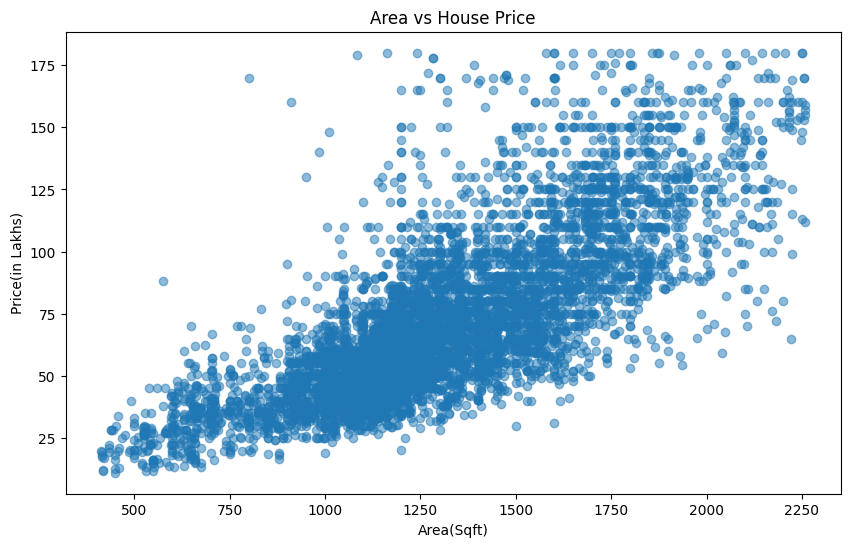

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Area'],df['price'],alpha=0.5)
plt.title("Area vs House Price")
plt.xlabel("Area(Sqft)")
plt.ylabel("Price(in Lakhs)")
plt.show()

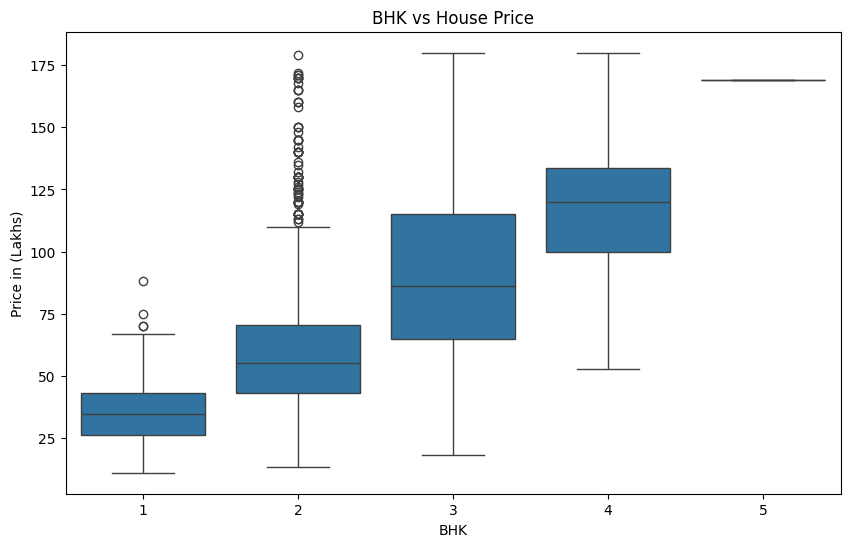

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='bhk',y='price')
plt.title("BHK vs House Price")
plt.xlabel("BHK")
plt.ylabel("Price in (Lakhs)")
plt.show()

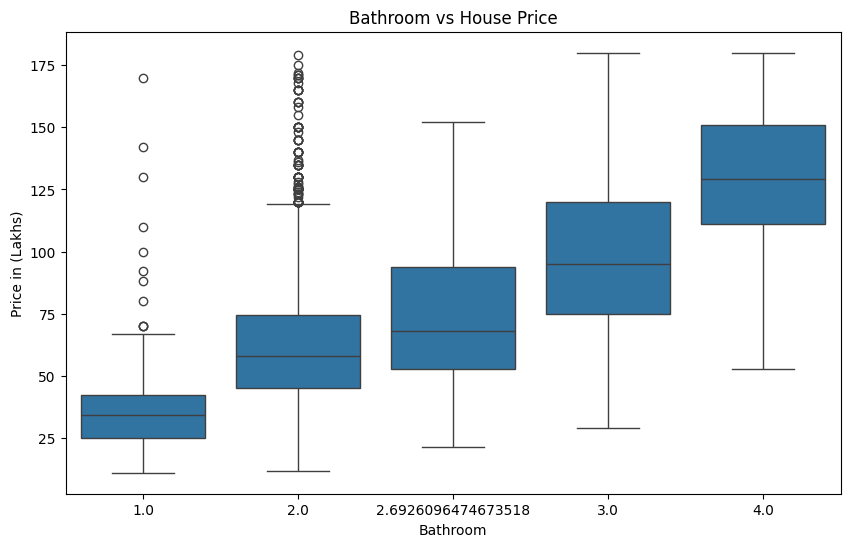

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='bath',y='price')
plt.title("Bathroom vs House Price")
plt.xlabel("Bathroom")
plt.ylabel("Price in (Lakhs)")
plt.show()

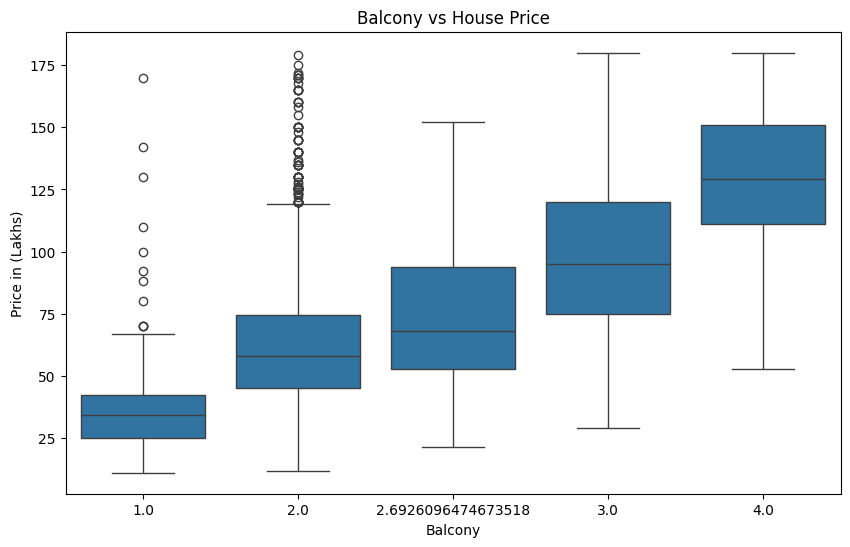

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='balcony',y='price')
plt.title("Balcony vs House Price")
plt.xlabel("Balcony")
plt.ylabel("Price in (Lakhs)")
plt.show()

In [ ]:
average_price_by_location = df.groupby('location')['price'].mean().sort_values(ascending=False)

In [ ]:
average_price_by_location.head(10 )

,price
location,
Hebbal Kempapura,141.416667
Iblur Village,137.833333
Talaghattapura,135.875000
Thigalarapalya,133.251000
Frazer Town,130.045000
Karuna Nagar,129.666667
Indira Nagar,127.000000
Rajaji Nagar,125.916364
Bommenahalli,124.000000


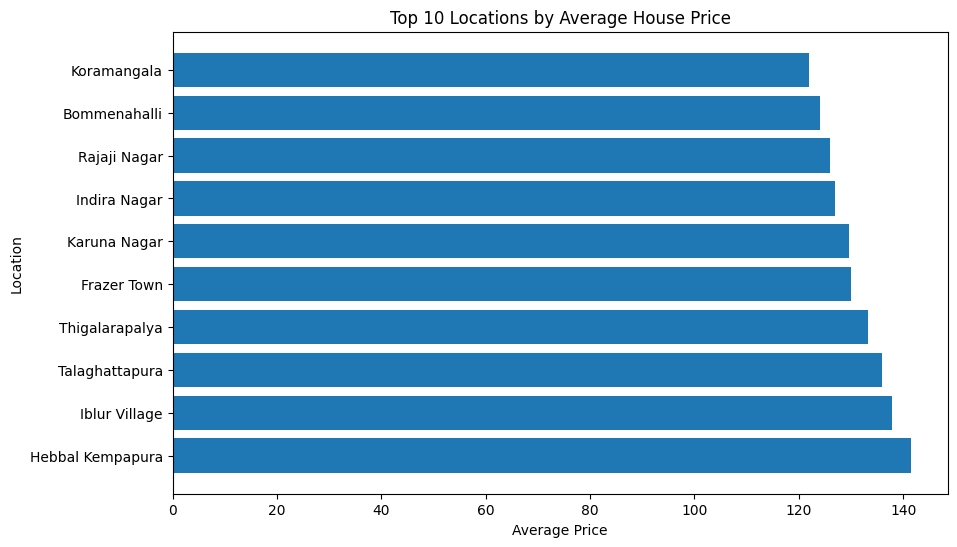

In [ ]:
top_locations = average_price_by_location.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_locations.index, top_locations.values)

plt.xlabel("Average Price")
plt.ylabel("Location")
plt.title("Top 10 Locations by Average House Price")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,f1_score,mean_absolute_error

In [ ]:
x = df.drop('price',axis=1)
y = df['price']

x = pd.get_dummies(x, drop_first=True)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)
print(y_pred)

[103.30374625  85.21749203  58.43185666 ... 159.57355387  49.448752
  96.47092678]


In [ ]:
lr.score(x_train,y_train)

0.7100410218907234

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R2 Score: 0.7006169855912191
MAE: 13.46281178940679
RMSE: 18.698133424912257


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred = rf.predict(x_test)
print(y_pred)

[106.50608333  95.563275    54.18778333 ... 132.33666667  42.046
  93.64325   ]


In [ ]:
rf.score(x_train,y_train)

0.927883638616358

In [ ]:
print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)** 0.5)

R2 Score: 0.6661921889663676
MAE: 13.275284400014648
RMSE: 19.743899124524923


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(x_train,y_train)

GradientBoostingRegressor()

In [ ]:
print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)** 0.5)

R2 Score: 0.6661921889663676
MAE: 13.275284400014648
RMSE: 19.743899124524923


In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor()


In [ ]:
xgb = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train, y_train)

y_pred3 = xgb.predict(x_test)

print("Training R2:", xgb.score(x_train, y_train))
print("Testing R2:", xgb.score(x_test, y_test))
print("MAE:", mean_absolute_error(y_test, y_pred3))
print("RMSE:", mean_squared_error(y_test, y_pred3) ** 0.5)

Training R2: 0.7753512785614088
Testing R2: 0.7202620039061132
MAE: 12.770681809659562
RMSE: 18.07425502313617


In [ ]:
result = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","Gradient Boosting","XGBoost"],
    "R2 Score":[0.7006169855912191,0.6644897664495457, 0.6644897664495457,0.7202620039061132],
    "MAE":[13.46281178940679, 13.241089380349553,13.241089380349553, 12.770681809659562],
    "RMSE":[18.698133424912257,19.794182117183578,19.794182117183578,18.07425502313617]
})

print(result)

               Model  R2 Score        MAE       RMSE
0  Linear Regression  0.700617  13.462812  18.698133
1      Random Forest  0.664490  13.241089  19.794182
2  Gradient Boosting  0.664490  13.241089  19.794182
3            XGBoost  0.720262  12.770682  18.074255


In [ ]:
result.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
3,XGBoost,0.720262,12.770682,18.074255
0,Linear Regression,0.700617,13.462812,18.698133
1,Random Forest,0.664490,13.241089,19.794182
2,Gradient Boosting,0.664490,13.241089,19.794182


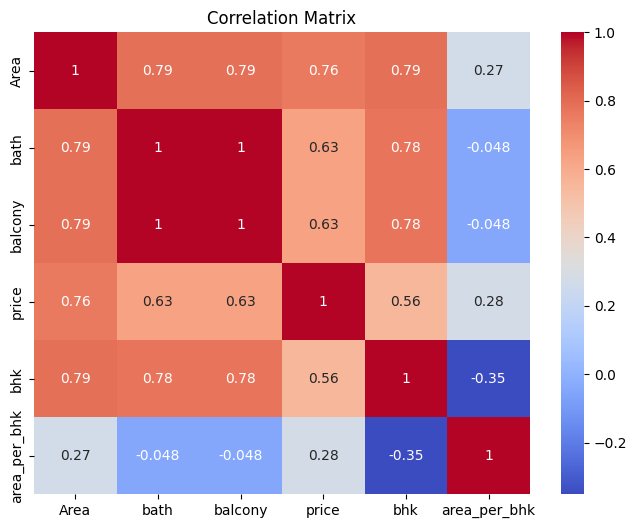

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

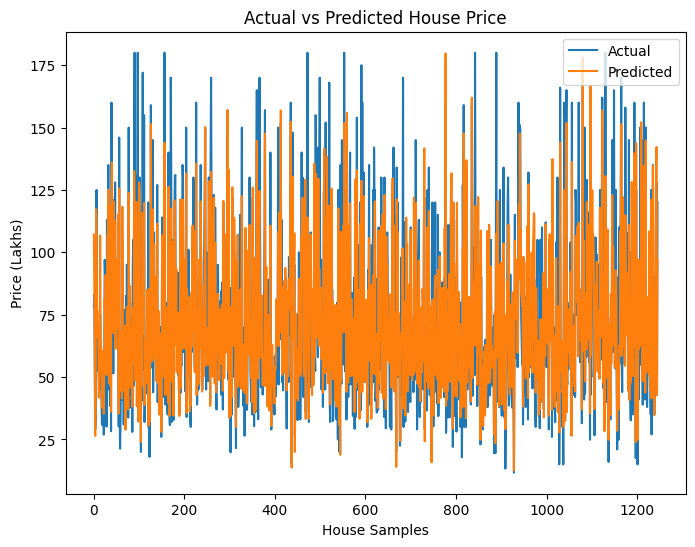

In [ ]:
y_pred = xgb.predict(x_test)

plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plot_df.plot(kind="line", figsize=(8, 6))

plt.title("Actual vs Predicted House Price")
plt.xlabel("House Samples")
plt.ylabel("Price (Lakhs)")
plt.show()

In [ ]:
import joblib

joblib.dump(xgb, "house_price_model.pkl")


from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(x_train.columns.tolist())

['Area', 'bath', 'balcony', 'bhk', 'area_per_bhk', 'area_type_Carpet  Area', 'area_type_Plot  Area', 'area_type_Super built-up  Area', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_9th Phase JP Nagar', 'location_AECS Layout', 'location_Abbigere', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Ambedkar Nagar', 'location_Anandapura', 'location_Ardendale', 'location_Attibele', 'location_BTM 2nd Stage', 'location_Balagere', 'location_Banashankari', 'location_Bannerghatta Road', 'location_Battarahalli', 'location_Begur', 'location_Begur Road', 'location_Bellandur', 'location_Bharathi Nagar', 'location_Bhoganhalli', 'location_Billekahalli', 'location_Binny Pete', 'location_Bisuvanahalli', 'location_Bommanahalli', 'location_Bommasandra', 'location_Bommenahalli', 'location_Brookefield', 'location_Budigere', 'location_CV Raman Nagar', 'location_Chandapura', 'location_Channasandra', 'location_Chik

In [ ]:
import joblib

joblib.dump(x_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [ ]:
from google.colab import files

files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Test prediction directly from your trained model
test_data = x_test.iloc[[0]]

print("Actual Price:", y_test.iloc[0])

prediction = xgb.predict(test_data)

print("Predicted Price:", prediction[0])

Actual Price: 78.0
Predicted Price: 107.136765


In [ ]:
predictions = xgb.predict(x_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,78.0,107.136765
1,83.0,88.389610
2,56.9,61.979015
3,29.0,26.446817
4,32.0,43.823650
5,110.0,117.246735
6,125.0,106.603806
7,68.0,77.072212
8,70.0,76.502724
9,52.6,65.863731


In [66]:
import pandas as pd


area = 1000
bhk = 1
bath = 2
balcony = 1
location = "Whitefield"
area_type = "Built-up Area"


area_per_bhk = area / bhk


data = pd.DataFrame({
    "Area": [area],
    "bath": [bath],
    "balcony": [balcony],
    "bhk": [bhk],
    "area_per_bhk": [area_per_bhk]
})


location_column = "location_" + location

if location_column in x_train.columns:
    data[location_column] = 1

if area_type != "Built-up Area":
    area_column = "area_type_" + area_type

    if area_column in x_train.columns:
        data[area_column] = 1


data = data.reindex(columns=x_train.columns, fill_value=0)


prediction = xgb.predict(data)[0]

print("Predicted Price:", prediction, "Lakhs")

Predicted Price: 51.316525 Lakhs
